In [ ]:
for i in range(10,4,-1):
    print(i)

In [12]:
import pandas as pd
import numpy as np
import hnswlib
from time import time
import matplotlib.pyplot as plt

In [2]:
df = pd.read_json("hf://datasets/mteb/index-NFCorpus-test-intfloat_e5-small-v2/embedding.jsonl", lines=True)

d:\Dokumentumok\MSc\F3_TudLab\EX9BLV_HNSW_Preordering\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
print(f"Count: {len(df)}")
print(df.keys())
print(f"Dim: {len(df.vector[0])}")
print(f"{df.vector[0][0]} - {type(df.vector[0][0])}")
# print(type(df.vector))
# print(type(df.vector[0]))
# print(type(np.asarray(df.vector)))
# dx = map(np.asarray, df.vector)
# print(type(dx))
# print(type(np.asarray(dx)))


# max([len(v) for v in df.vector])
# for v in df.vector:
#     print(len(v))

Count: 3633
Index(['id', 'vector', 'text'], dtype='str')
Dim: 384
-0.089692406356334 - <class 'float'>


In [4]:
class KNN:
    def __init__(self, data):
        self._data = data

    def euclidian_distance(x, y):
        sum = 0
        for i in range(0, min(len(x),len(y))):
            sum += (y[i] - x[i]) ** 2
        return np.sqrt(sum)

    def get_KNN(self, q, k, distance = euclidian_distance):
        dists = [distance(q, v) for v in self._data]
        knn_index = np.argsort(dists)[1:k+1]
        # return np.array([self._data[i] for i in knn_index])
        return np.array(knn_index)

In [5]:
class HNSW_benchmark:
    def __init__(self, data, M = 16, ef_construction = 128):
        # alap adatok
        self._data = [np.array(v) for v in data]
        self._M = M
        self._ef_construction = ef_construction
        # KNN init
        self._knn = KNN(data)
        # HNSW init
        self._hnsw = hnswlib.Index(space        = 'l2',
                                   dim          = len(self._data[0]))
        self._hnsw.init_index(max_elements      = len(self._data),
                              M                 = self._M,
                              ef_construction   = self._ef_construction)
        self._hnsw.add_items(data               = self._data)

    def reconstruct_HNSW(self):
        self._hnsw.init_index(max_elements      = len(self._data),
                              M                 = self._M,
                              ef_construction   = self._ef_construction)
        self._hnsw.add_items(data               = self._data)

    def run(self, q, n_tries = 1000, k = 10, ef_search = 40):
        # Várt eredmény (recall = 1) kiszámítása
        R_E = self._knn.get_KNN(q, k)
        R_E = set(R_E)

        # HNSW keresési beállítások
        self._hnsw.set_ef(ef_search)

        # HNSW futtatása n_tries-szor, és recall számítása
        sum_recall = 0
        for i in range(0, n_tries):
            R_A = self._hnsw.knn_query([q], k, filter=(lambda x: KNN.euclidian_distance(self._data[x], q) > 0))
            sum_recall += len(R_E & set(R_A[0][0]))

        return sum_recall / (k * n_tries)

    

In [16]:
def calculate_lid(data, k=100):
    vectors = np.asarray(list(data), dtype=np.float32)
    n = len(vectors)

    if n <= k:
        raise ValueError(f"Dataset must contain more than k={k} vectors.")

    knn = KNN(vectors)
    lid_values = np.full(n, np.nan, dtype=np.float64)

    for i, vector in enumerate(vectors):
        neighbor_indices = knn.get_KNN(vector, k)
        distances = np.array([
            KNN.euclidian_distance(vector, vectors[j])
            for j in neighbor_indices
        ])

        distances = distances[distances > 0]

        if len(distances) < k:
            raise ValueError(f"Dataset must contain more than k={k} vectors.")

        max_distance = distances[-1]
        log_ratios = np.log2(distances / max_distance) # ln jobb lenne, de mindegy a rangsorolás szempontjából, mivel mindegyik szig. mon. növ. fv
        lid_values[i] = -((np.sum(log_ratios) / k) ** -1)

    return lid_values

In [ ]:
# KNN & HNSW inicializálás
knn = KNN(df.vector)

hnsw = hnswlib.Index(space  = 'l2',
                     dim    = len(df.vector[0]))

hnsw.init_index(max_elements    = len(df.vector),
                M               = 16,
                ef_construction = 128)

# hnsw.add_items(data = [np.array(v) for v in df.vector],
#                ids  = df.id)
hnsw.add_items(data = [np.array(v) for v in df.vector])
# hnsw.add_items(data = [[1,2,3,4],[2,3,4,5],[3,4,5,6]])

In [ ]:
q = df.vector[109]
k = 10

# KNN keresés
start = time()
res_knn = knn.get_KNN(q, k)
end = time()
# print(res_knn[0])
for i in range(0,k):
    # print(f"{i+1}: {KNN.euclidian_distance(q, df.vector[res_knn[i]])}") # ha id-ket kérünk
    # print(f"{i+1}: {df.id[res_knn[i]]}") # ha distance-eket kérünk
    print(f"{i+1}: {df.id[res_knn[i]]} at distance: {KNN.euclidian_distance(q, df.vector[res_knn[i]])}") # ha mindent kérünk
# print(list(res_knn))
print(f"{(end-start)*1000} ms")

#HNSW keresés
hnsw.set_ef(10)
start = time()
# res_hnsw = hnsw.knn_query([q], k+1)[0][0][1:k+1]
res_hnsw = hnsw.knn_query([q], k, filter=(lambda x: x != 109))[0][0]
end = time()
# print(res_hnsw[0])
# print(df.vector[res_hnsw[0]])
for i in range(0,k):
    # print(f"{i+1}: {KNN.euclidian_distance(q, df.vector[res_hnsw[i]])}") # ha id-ket kérünk
    # print(f"{i+1}: {df.id[res_hnsw[i]]}") # ha distance-eket kérünk
    print(f"{i+1}: {df.id[res_knn[i]]} at distance: {KNN.euclidian_distance(q, df.vector[res_hnsw[i]])}") # ha mindent kérünk
print(f"{(end-start)*1000} ms")

In [8]:
# HNSW_benchmark teszt futás
bm = HNSW_benchmark(data=df.vector, M=16, ef_construction=128)

rng = np.random.default_rng(42)
indices = rng.choice(len(df), size=100, replace=False)
queries = [df.vector.iloc[i] for i in indices]

start = time()
recalls = [bm.run(query, n_tries=1, k=10, ef_search=40) for query in queries]
elapsed = time() - start

print(f"Average recall: {np.mean(recalls):.4f}")
print(f"Total time: {elapsed:.3f} seconds")
print(f"Average time per query: {elapsed / len(queries) * 1000:.3f} ms")

Average recall: 0.9840
Total time: 56.930 seconds
Average time per query: 569.301 ms


In [11]:
# print(np.argwhere(df.vector, q))
# print(df.vector.keys)

a = set([1, 1, 2, 1, 4, 3])

print(a)

{1, 2, 3, 4}


np.float64(-0.5)

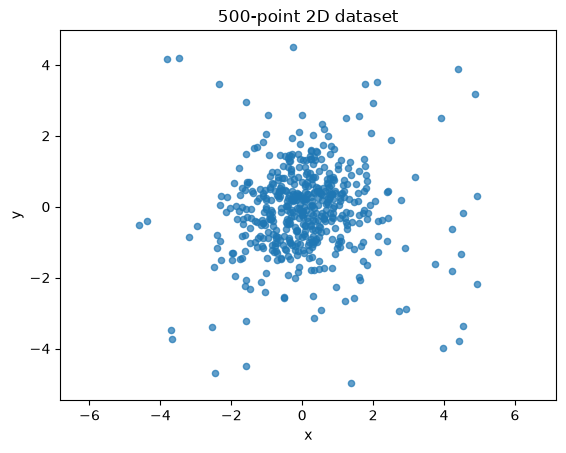

In [14]:
rng_2d = np.random.default_rng(42)

clustered = rng_2d.normal(loc=0, scale=1, size=(450, 2))
scattered = rng_2d.uniform(low=-5, high=5, size=(50, 2))

points_2d = np.vstack([clustered, scattered])
rng_2d.shuffle(points_2d)

plt.scatter(points_2d[:, 0], points_2d[:, 1], s=20, alpha=0.7)
plt.title("500-point 2D dataset")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

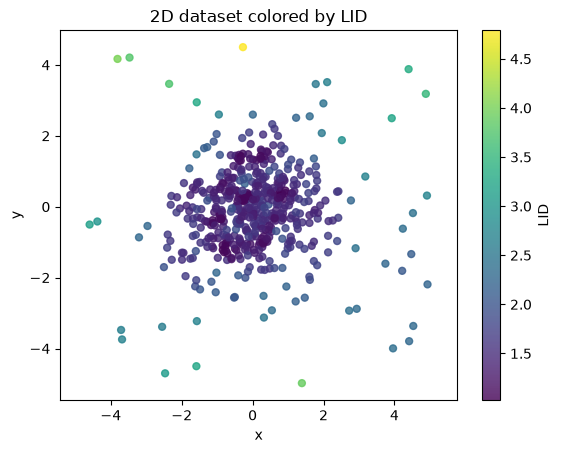

In [20]:
lid_values_2d = calculate_lid(points_2d, k=50)

plt.scatter(
    points_2d[:, 0],
    points_2d[:, 1],
    c=lid_values_2d,
    cmap="viridis",
    s=25,
    alpha=0.8,
)
plt.colorbar(label="LID")
plt.title("2D dataset colored by LID")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()